In [702]:
import xradar as xd
import sys
import wradlib as wrl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import cmap
from scipy.ndimage import (
    median_filter,
    gaussian_filter,
    generic_filter,
    uniform_filter,
    label,
)
from scipy.spatial import cKDTree
from pyproj import Transformer
import rioxarray

In [703]:
# PLOTERS
###############################################################################

def plot_features(ax):
    departments = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='10m',
        edgecolor='black',
        facecolor='never',
        linewidth=0.6,
        linestyle='-'
    )
    ax.add_feature(departments, zorder=3)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5)
    # Optional: add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

In [704]:
# HELPERS
###############################################################################

def texture_std(x):

    valid = np.isfinite(x)

    if np.sum(valid) < 3:
        return np.nan

    return np.nanstd(x)

def compute_texture(field, size=(1, 5)):
    """
    Compute local texture of a radar field.
    """

    arr = field.values.copy()

    tex = generic_filter(
        arr,
        texture_std,
        size=size,
        mode="nearest"
    )

    return xr.DataArray(
        tex,
        dims=field.dims,
        coords=field.coords
    )

In [771]:
filepath = "data/raw/Bogota/2024/10/21/1399BOG-20241021-200100-PPIVol-7081.nc"
dtree = xd.io.open_cfradial1_datatree(filepath, decode_times=False)

swp = dtree["/sweep_0"]
print(swp)

<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:                          (sweep: 1, frequency: 1, azimuth: 1560,
                                          range: 960)
    Coordinates:
      * azimuth                          (azimuth) float32 6kB 0.01373 ... 359.8
        time                             (azimuth) float64 12kB 9.0 9.0 ... 9.0 9.0
        elevation                        (azimuth) float32 6kB ...
      * range                            (range) float32 4kB 31.25 ... 5.997e+04
        latitude                         float64 8B ...
        longitude                        float64 8B ...
        altitude                         float64 8B ...
    Inherited coordinates:
      * frequency                        (frequency) float32 4B 9.3e+09
    Dimensions without coordinates: sweep
    Data variables: (12/31)
        radar_measured_transmit_power_h  (azimuth) float32 6kB ...
        radar_measured_transmit_power_v  (azimuth) float32 6kB ...
        pulse_width 

In [772]:
radar_alt = float(dtree["/"]["altitude"].values)
radar_lon = float(dtree["/"]["longitude"].values)
radar_lat = float(dtree["/"]["latitude"].values)

site = (radar_lon, radar_lat, radar_alt)

azimuth   = swp["azimuth"].data
range     = swp["range"].data
elangle   = swp["elevation"].data

elangle = dtree.sweep_fixed_angle.values
print(elangle)

azimuth_2d, range_2d = np.meshgrid(azimuth, range, indexing='ij')
elevation_2d = np.broadcast_to(elangle[:,np.newaxis], azimuth_2d.shape)

xyz,aeqd = wrl.georef.polar.spherical_to_xyz(
    range_2d,
    azimuth_2d,
    elevation_2d,
    site,
)

x = xyz[...,0]
y = xyz[...,1]
z = xyz[...,2]

transformer = Transformer.from_crs(
    aeqd,
    "EPSG:4326",
    always_xy=True,
)
lon,lat = transformer.transform(x,y)
alt = z

radar_lon = np.squeeze(lon)
radar_lat = np.squeeze(lat)
radar_z = np.squeeze(z)

swp.coords["gate_latitude"] = (('azimuth', 'range'), radar_lat)
swp.coords["gate_longitude"] = (('azimuth', 'range'), radar_lon)
swp.coords["gate_height"] = (('azimuth', 'range'), radar_z)

print(dtree)
print(swp.data_vars)

[2.5]
<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 9.3e+09
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       latitude             float64 8B 4.675
│       longitude            float64 8B -74.11
│       altitude             float64 8B 2.57e+03
│       time_coverage_start  |S25 25B ...
│       time_coverage_end    |S25 25B ...
│       sweep_group_name     (sweep) <U7 28B 'sweep_0'
│       sweep_fixed_angle    (sweep) float32 4B 2.5
│   Attributes:
│       Conventions:      Cf/Radial instrument_parameters radar_parameters
│       title:            PPIVol
│       institution:      EEC
│       references:       EEC
│       source:           EDGE
│       history:          original
│       comment:          PPIVol
│       instrument_name:  1399BOG
│       site_name:        1399BOG
├── Group: /radar_parameters
│       Dimensions:

In [773]:
alpha=0.01
rhohv_thresh=0.85
snr_thresh=8.5
ncp_thresh=0.3
texture_thresh=20
zdr_thresh=7

In [774]:
###########################################################################
# VARIABLES
###########################################################################
DBZH = swp["DBZH"]
PHIDP = swp["PHIDP"]
KDP = swp["KDP"]
RHOHV = swp["RHOHV"]
NCP = xr.ufuncs.minimum(
    swp["NCPH"],
    swp["NCPV"]
)
SNR = xr.ufuncs.minimum(
    swp["SNRHC"],
    swp["SNRVC"]
)
ZDR = swp["ZDR"]


In [775]:
###########################################################################
# 1. METEOROLOGICAL MASK
###########################################################################

#met_mask = (
#      (RHOHV > rhohv_thresh)
#    & (SNR > snr_thresh)
#    #& (NCP > ncp_thresh) 
#    & (DBZH > 5)
#)

In [776]:

# 1. RECUPERAR LES MATRIUS DES DEL TEU SWEEP
# Assegura't que els noms coincideixen amb les variables de dades del teu DataTree
zh_db = DBZH.values     # Reflectivitat horitzontal en dBZ
zdr_db = ZDR.values    # Reflectivitat diferencial en dB
rhohv = RHOHV.values    # Coeficient de correlació creuada (0 a 1)

# 2. CALCULAR ELS COMPONENTS EN ESCALA LINEAL DE L'EQUACIÓ DE KILAMBI
# Transformació de dB a lineal de ZDR i de l'arrel quadrada (ZDR^0.5)
zdr_linear = 10.0 ** (zdr_db / 10.0)
zdr_sqrt_linear = 10.0 ** (zdr_db / 20.0)

# 3. EXECUTAR L'EQUACIÓ COMPLETA DEL DR
# Calculem el numerador i el denominador de la ràtio de despolarització
numerador = zdr_linear + 1.0 - (2.0 * zdr_sqrt_linear * rhohv)
denominador = zdr_linear + 1.0 + (2.0 * zdr_sqrt_linear * rhohv)

# Evitar divisions per zero si el denominador és nul o invàlid
with np.errstate(divide='ignore', invalid='ignore'):
    dr_linear = numerador / denominador
    # El paper finalment passa el resultat a escala logarítmica (dB)
    dr_db = 10.0 * np.log10(dr_linear)

# Substituir potencials valors infinits o nuls per un valor neutre baix
dr_db = np.nan_to_num(dr_db, nan=-99.0, posinf=-99.0, neginf=-99.0)

# ==========================================================
# 4. APLICAR ELS LLINDARS DE TALL DEL PAPER (HARD MASKING)
# ==========================================================
# Segons Kilambi et al. (2018), els hidrometeors (pluja real) tenen valors 
# de DR molt baixos (normalment inferiors a -12 dB o -15 dB).
# Els insectes, clutter i soroll urbà solen tenir valors de DR superiors a -10 dB.

# Creem la màscara dura (True = Esborrar cel·la per no-meteorològica)
llindar_tall = -12.0
mascara_meteo = dr_db < llindar_tall

# 5. INTEGRAR LA NOVA VARIABLE AL TEU DATATREE
swp["DR"] = xr.DataArray(dr_db, dims=["azimuth","range"])
swp["DR"].attrs["long_name"] = "Dual-Polarization Depolarization Ratio"
swp["DR"].attrs["units"] = "dB"

print("Variable DR calculada amb èxit!")
print(f"Cel·les detectades com a soroll/insectes (DR > {llindar_tall} dB): {np.sum(~mascara_meteo)}")

Variable DR calculada amb èxit!
Cel·les detectades com a soroll/insectes (DR > -12.0 dB): 1294001


In [777]:
DR = swp["DR"]
met_mask = (
      (DR < llindar_tall)
    & (SNR > snr_thresh)
)

In [778]:
###########################################################################
# 2. REMOVE ISOLATED PIXELS
###########################################################################

#density = uniform_filter(
#    met_mask.astype(float),
#    size=(3,5)
#)

#met_mask = density > 0.5

mask_vals = met_mask.values.copy()

labels, num = label(mask_vals)

sizes = np.bincount(labels.ravel())

min_size = 3

small = sizes < min_size

# Preserve background
small[0] = False

remove_mask = small[labels]

mask_vals[remove_mask] = False

met_mask = xr.DataArray(
    mask_vals,
    dims=met_mask.dims,
    coords=met_mask.coords
)

In [779]:
###########################################################################
# 5. PHIDP TEXTURE
###########################################################################

phidp = PHIDP

textura_phidp = wrl.util.texture(PHIDP.values)
textura_phidp = np.nan_to_num(textura_phidp, nan=0.0)

tPHIDP = xr.DataArray(
    textura_phidp,
    dims=phidp.dims,
    coords=phidp.coords
)

In [780]:
###########################################################################
# 6. PHIDP QUALITY MASK
###########################################################################

met_mask = (
    met_mask
    & (tPHIDP < texture_thresh)
)

In [781]:
###########################################################################
# 3. FILTER REFLECTIVITY
###########################################################################

cDBZH = xr.where(
    met_mask,
    DBZH,
    np.nan
)

In [782]:
###########################################################################
# 7. FILTERED PHIDP
###########################################################################

fPHIDP = xr.where(
    met_mask,
    PHIDP,
    np.nan
)

In [783]:
gate_latitude  = swp.coords["gate_latitude"].values
gate_longitude = swp.coords["gate_longitude"].values
gate_height    = swp.coords["gate_height"].values

In [784]:
import numpy as np
import rioxarray
from scipy.interpolate import interpn

dem_filepath = "GMTED2010S10W090_075/10s090w_20101117_gmted_mea075.tif"

# 1. Carregar el DEM i extreure els vectors de l'eix X (longitud) i Y (latitud)
dem = rioxarray.open_rasterio(dem_filepath, mask_and_scale=True).squeeze()
dem_lon = dem.x.values
dem_lat = dem.y.values

# Si les latituds van de nord a sud (valors decreixents), invertim l'eix i la matriu 
# perquè interpn necessita obligatòriament vectors estrictament creixents
if dem_lat[0] > dem_lat[-1]:
    dem_lat = dem_lat[::-1]
    dem_values = dem.values[::-1, :]
else:
    dem_values = dem.values

# 2. Interpola directament sobre la teva malla polar del radar (en NumPy pur)
# Creem la llista de punts de destinació on vols extreure l'elevació
punts_radar = np.stack((gate_latitude, gate_longitude), axis=-1)

# Executem la interpolació lineal (fora dels límits del DEM assignarà un valor de 0.0)
terrain_height = interpn(
    (dem_lat, dem_lon), 
    dem_values, 
    punts_radar, 
    method="linear", 
    bounds_error=False, 
    fill_value=0.0
)

# 3. Eliminar qualsevol valor nul residual (NaN)
terrain_height = np.nan_to_num(terrain_height, nan=0.0)



In [785]:
beamwidth = float(dtree["radar_parameters"]["radar_beam_width_h"].values)

r_distances = swp.coords["range"].values

beamradius = wrl.util.half_power_radius(r_distances, beamwidth)

pbb = wrl.qual.beam_block_frac(terrain_height, gate_height, beamradius)
cbb = wrl.qual.cum_beam_block_frac(np.ma.masked_invalid(pbb))

cbb_clean = np.ma.filled(cbb, fill_value=0.0)

print(cbb_clean)

swp["CBB"] = xr.DataArray(cbb_clean, dims=["azimuth", "range"])

swp["CBB"].attrs["long_name"] = "Cumulative Beam Blockage Fraction"
swp["CBB"].attrs["units"] = "1"
swp["CBB"].attrs["comment"] = "Calculat usant DEM GMTED2010 a 250m"


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/home/cesc/anaconda3/envs/radar-env/lib/python3.11/site-packages/wradlib/qual.py:181: RuntimeWarning: invalid value encountered in sqrt
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)
/home/cesc/anaconda3/envs/radar-env/lib/python3.11/site-packages/wradlib/qual.py:181: RuntimeWarning: invalid value encountered in arcsin
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)


In [786]:
dbzh_original = cDBZH.values
cbb_data = swp["CBB"].values
print(cbb_data)

dbzh_corregit = np.copy(dbzh_original)

mask_compensar = (cbb_data >= 0.1) & (cbb_data <= 0.5)

dbzh_corregit[mask_compensar] = dbzh_corregit[mask_compensar] - 10.0 * np.log10(1.0 - cbb_data[mask_compensar])

mask_eliminar = cbb_data > 0.5
dbzh_corregit[mask_eliminar] = np.nan

DBZH_terrain_corrected = xr.DataArray(dbzh_corregit, dims=["azimuth", "range"])


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [787]:
############################################################################
## 4. INITIAL PHIDP SMOOTHING
############################################################################
## 1. interpolate gaps
#
#phidp = fPHIDP
#
#phidp = phidp.interpolate_na(
#    dim="range",
#    method="linear",
#    limit=10
#)
#
## 2. running median
#phidp_vals = median_filter(
#    phidp.values,
#    size=(1,5)
#)
#
#sPHIDP = xr.DataArray(
#    phidp_vals,
#    dims=phidp.dims,
#    coords=phidp.coords
#)
#
## 4. radial running mean
#sPHIDP = sPHIDP.rolling(
#    range=25,
#    center=True
#).mean()

In [788]:
############################################################################
## 8. FINAL PHIDP SMOOTHING
############################################################################
#
#vals = np.nan_to_num(
#    fPHIDP.values,
#    nan=0
#)
#
#vals = median_filter(
#    vals,
#    size=(1,5)
#)
#
#vals = gaussian_filter(
#    vals,
#    sigma=(0,1)
#)

In [789]:
# Suposem que 'fPHIDP' és el teu DataArray original amb els NaNs de la textura
phidp_inicial = fPHIDP.copy()

# ===========================================================================
# PAS 1: INTERPOLACIÓ GEOMÈTRICA DE BUITS (Justificació: Hubbert & Bringi, 1995)
# ===========================================================================
# Omplim els buits petits (fins a 10 cel·les) per mantenir la continuïtat del raig.
# Això evita que les vores de la pluja caiguin a zero de forma artificial.
phidp_interp = phidp_inicial.interpolate_na(
    dim="range",
    method="linear",
    limit=10
)

# ===========================================================================
# PAS 2: FILTRE DE MEDIANA EN 2D (Eliminació de soroll d'impuls / valors atípics)
# ===========================================================================
# Escaneja la matriu cel·la per cel·la aplicant una finestra radial de 5 píxels.
# S'executa en NumPy pur sobre els valors interpolats.
vals_mediana = median_filter(
    phidp_interp.values,
    size=(1, 5)
)

# Reconstruïm el DataArray per poder aplicar les funcions geomètriques de xarray
phidp_mediana = xr.DataArray(
    vals_mediana,
    dims=phidp_interp.dims,
    coords=phidp_interp.coords
)

# ===========================================================================
# PAS 3: MITJANA MÒBIL RADIAL ADAPTATIVA (Suavitzat final de la línia base)
# ===========================================================================
# Apliquem una finestra de 25 cel·les per homogeneïtzar la fase abans de derivar.
# SOLUCIÓ CRÍTICA: 'min_periods=1' impedeix que els NaNs grans (com muntanyes esborrades)
# es propaguin com una taca d'oli i destrueixin les zones de pluja neta.
sPHIDP = phidp_mediana.rolling(
    range=25,
    center=True,
    min_periods=1
).mean()

# ===========================================================================
# PAS 4: BLOCATGE DE SEGURETAT FINAL PER A WRADLIB (fillna)
# ===========================================================================
# L'algorisme de convolució de Lanczos de wradlib llançarà un error matemàtic
# si troba algun NaN residual a la matriu. Omplim els NaNs que hagin quedat
# (exclusivament a les zones de cel completament buit a la perifèria) amb 0.0.
sPHIDP_clean = sPHIDP.fillna(0.0)



In [790]:
# 1. Agafem la variable del pas anterior (el suavitzat adaptatiu)
vals = np.copy(sPHIDP_clean.values)

# ===========================================================================
# PAS 9: FORÇAT DE MONOTONICITAT (Justificació: Hubbert & Bringi, 1995)
# ===========================================================================
# Corregim cel·la per cel·la al llarg de cada raig d'azimut per assegurar 
# que la fase mai decreix i eliminem el risc de KDP negatiu.
for az in np.arange(vals.shape[0]):
    ray = vals[az]
    for i in np.arange(1, len(ray)):
        if np.isfinite(ray[i-1]) and np.isfinite(ray[i]):
            if ray[i] < ray[i-1]:
                ray[i] = ray[i-1]
    vals[az] = ray

# ===========================================================================
# PAS 10: FILTRES DE MEDIANA FINALS (Poliment de la línia creixent)
# ===========================================================================
# Apliquem la seqüència exacta de filtres de mediana del teu codi (mida 4 i 8)
# per eliminar qualsevol graó artificial generat pel bucle de monotonicitat.
vals = median_filter(vals, size=(1, 4))
vals = median_filter(vals, size=(1, 8))

# ===========================================================================
# PAS 11: RECONSTRUCCIÓ DE LA VARIABLE I MÀSCARA METEOROLÒGICA
# ===========================================================================
# Apliquem de forma estricta la teva màscara de control de qualitat (met_mask)
# per assegurar-nos que fora de les zones de pluja el mapa quedi net (NaN).
vals_with_nan = np.copy(vals)
vals_with_nan[~met_mask.values] = np.nan

sPHIDP = xr.DataArray(
    vals_with_nan,
    dims=fPHIDP.dims,
    coords=fPHIDP.coords
)

In [791]:
###########################################################################
# 10. CLEAN KDP
###########################################################################

cKDP = xr.where(
    met_mask,
    KDP,
    np.nan
)

In [792]:
###########################################################################
# 10.5. CREATE KDP FROM FILTERED PHIDP
###########################################################################
#dKDP = wrl.dp.kdp_from_phidp(
#    fPHIDP,
#    winlen=31,
#    method="lanczos_conv"
#)
#
#vals = median_filter(
#    dKDP.values,
#    size=(1,15)
#)
#
#vals = median_filter(
#    dKDP.values,
#    size=(1,25)
#)
#
#vals = median_filter(
#    dKDP.values,
#    size=(1,35)
#)
#dKDP = xr.DataArray(
#    vals,
#    dims=dKDP.dims,
#    coords=dKDP.coords
#)


In [793]:
r_metres = swp.coords["range"].values
resolucio_metres = r_metres[1] - r_metres[0]  # Això sol donar 62.5m o 125m segons el radar

# 2. CONVERTIR HO A QUILÒMETRES (Requisit físic del KDP)
dr_km = resolucio_metres / 1000.0
print(f"Resolució espacial del radar detectada: {resolucio_metres} metres ({dr_km} km)")
# ===========================================================================
# 1. CÀLCUL DEL KDP AMB LA FUNCIÓ OFICIAL DE WRADLIB
# ===========================================================================
# Enviem la matriu 'vals' (que prové del forçat de monotonicitat, 100% numèrica)
# Usem 'winlen=24' perquè és la longitud de finestra òptima per a la Banda X de Bogotà
# i el mètode 'lanczos_conv' que aplica una derivada de convolució d'alta precisió.
dKDP_calculat = wrl.dp.kdp_from_phidp(
    sPHIDP.values, 
    winlen=25,
    dr=dr_km,
    method="lanczos_conv"
)

# ===========================================================================
# 2. POST-NETEJA CRÍTICA (POST-PROCESSING) DEL KDP
# ===========================================================================

# --- Pas A: Eliminació de valors negatius artificials ---
# Per la física del radar, la fase només augmenta, per tant el KDP real ha de ser positiu.
# Els petits valors negatius són artefactes matemàtics de la convolució a les vores de la pluja.
# Els forcem a 0.0 de forma segura.
dKDP_net = np.where(dKDP_calculat < 0.0, 0.0, dKDP_calculat)

# --- Pas B: Filtre de Mediana final per homogeneïtzar els nuclis ---
# Apliquem un filtre de mediana suau radial (mida 3) per netejar qualsevol "pic elèctric" 
# o valor extrem aïllat generat durant la derivació numèrica.
dKDP_net = median_filter(dKDP_net, size=(1, 3))

# --- Pas C: Aplicació del Hard Masking de la màscara meteorològica ---
# Recuperem la teva màscara de control de qualitat (met_mask) per assegurar-nos que
# tot el cel buit, zones de soroll de fons o muntanyes severes quedin com a NaN.
dKDP_final = np.copy(dKDP_net)
dKDP_final[~met_mask.values] = np.nan

dKDP = xr.DataArray(
    dKDP_final,
    dims=cKDP.dims,
    coords=cKDP.coords,
)

Resolució espacial del radar detectada: 62.5 metres (0.0625 km)


In [794]:
###########################################################################
# 11. SPECIFIC ATTENUATION
###########################################################################

#A = alpha * cKDP
A = alpha * dKDP

###########################################################################
# 12. RANGE RESOLUTION
###########################################################################

dr = float(
    swp["range"][1] - swp["range"][0]
)

dr_km = dr / 1000.0

###########################################################################
# 13. PIA
###########################################################################

pia_vals = 2 * np.nancumsum(
    A.values * dr_km,
    axis=1
)

PIA = xr.DataArray(
    pia_vals,
    dims=A.dims,
    coords=A.coords
)

###########################################################################
# 14. ATTENUATION CORRECTED REFLECTIVITY
###########################################################################

cDBZH_attcorr = DBZH_terrain_corrected + PIA

###########################################################################
# 15. RAINFALL ESTIMATION
###########################################################################

# R(A)
R_A = 4120 * (A ** 1.03)

# R(KDP)
#R_KDP = 40.6 * (cKDP ** 0.85)
R_KDP = 160 * (dKDP_final ** 0.88)

R_Z = (10**(cDBZH_attcorr/10)/180)**(1/1.4)

In [795]:
swp["met_mask"] = met_mask

swp["sPHIDP"] = sPHIDP
swp["sPHIDP"].attrs["long_name"] = "Smoothed Phase Shift (PhiDP)"
swp["sPHIDP"].attrs["units"] = "degrees"

swp["tPHIDP"] = tPHIDP

swp["DBZH_terrain_corrected"] = DBZH_terrain_corrected
swp["DBZH_terrain_corrected"].attrs["long_name"] = "Reflectivity corrected for beam blockage"
swp["DBZH_terrain_corrected"].attrs["units"] = "dBZ"

swp["fPHIDP"] = fPHIDP

swp["cKDP"] = cKDP

swp["dKDP"] = dKDP

swp["A"] = A

swp["PIA"] = PIA

swp["cDBZH"] = cDBZH_attcorr

swp["R_A"] = R_A

swp["R_KDP"] = R_KDP

swp["R_Z"] = R_Z

In [796]:
number_of_colors = 30

In [797]:
var = "UH"

<xarray.DataArray 'UH' (azimuth: 1560, range: 960)> Size: 6MB
[1497600 values with dtype=float32]
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.216 5.217
    gate_longitude  (azimuth, range) float64 12MB -74.11 -74.11 ... -74.12
    gate_height     (azimuth, range) float64 12MB 2.571e+03 ... 5.397e+03
    latitude        float64 8B 4.675
    longitude       float64 8B -74.11
    altitude        float64 8B 2.57e+03
Attributes:
    long_name:  unfiltered_reflectivity_factor_h
    units:      dBZ


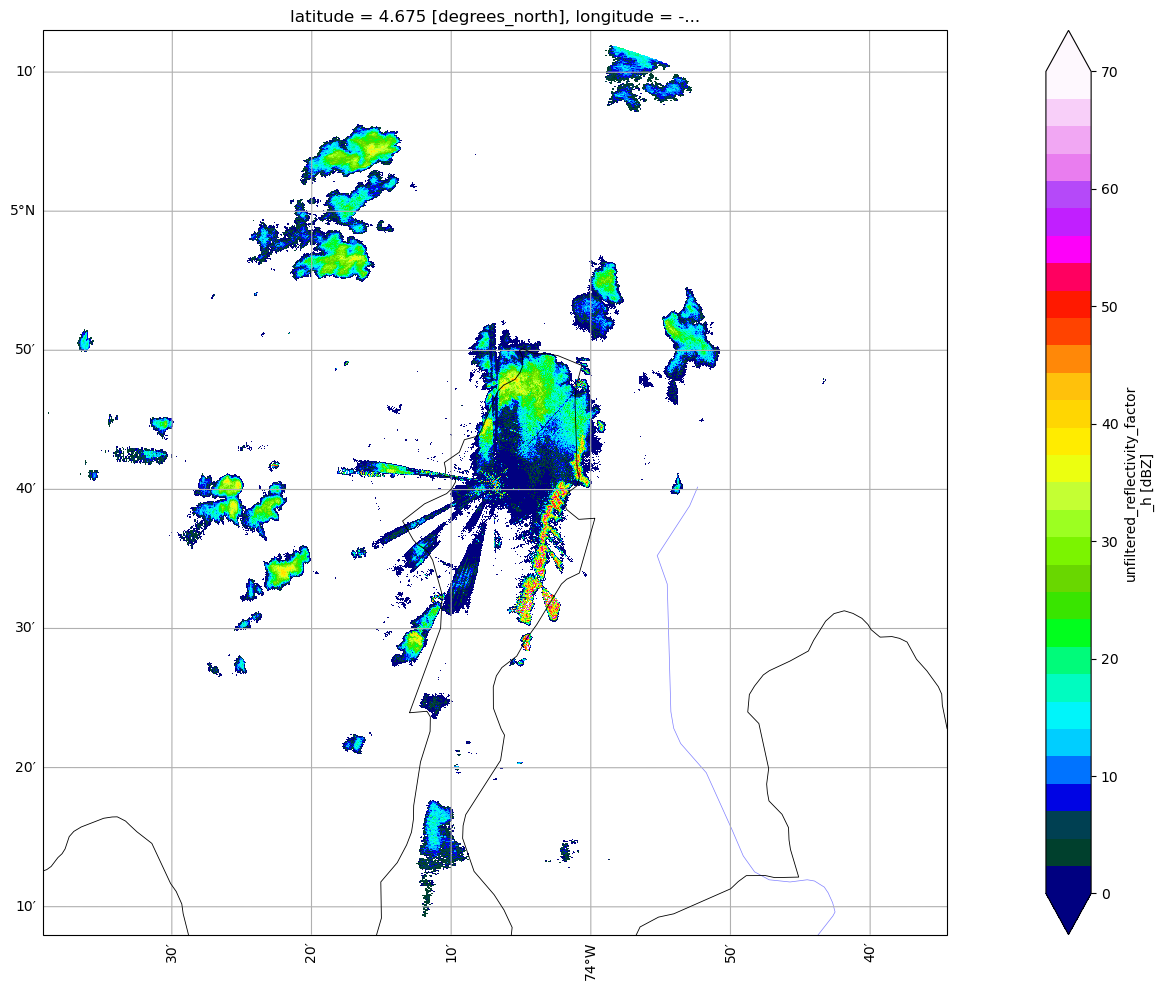

In [798]:
da = swp[f"{var}"]

print(da)


da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [799]:
var = "cDBZH"

<xarray.DataArray 'cDBZH' (azimuth: 1560, range: 960)> Size: 6MB
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ...,
       [ nan,  nan, 33.5, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.216 5.217
    gate_longitude  (azimuth, range) float64 12MB -74.11 -74.11 ... -74.12
    gate_height     (azimuth, range) float64 12MB 2.571e+03 ... 5.397e+03
    latitude        float64 8B 

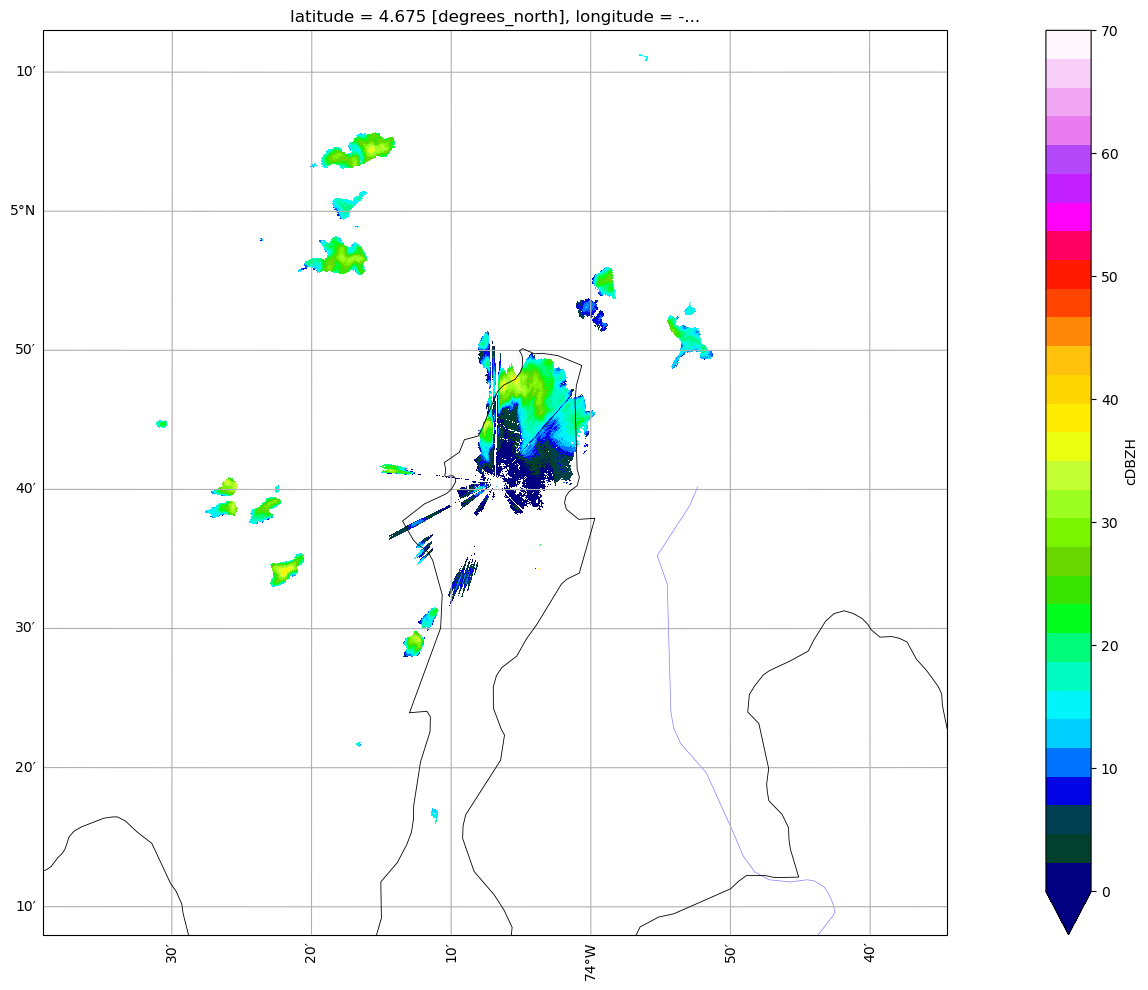

In [800]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [801]:
var = "ZDR"

<xarray.DataArray 'ZDR' (azimuth: 1560, range: 960)> Size: 6MB
array([[ 3.01,  3.38,  3.38, ...,  1.22,  1.31,  1.12],
       [ 4.04,  4.23,  4.32, ...,  0.84,  0.56,  0.56],
       [ 4.14, -1.69, -1.69, ...,  0.94,  0.65,  0.28],
       ...,
       [ 2.07,  3.48,  3.85, ..., -2.16, -2.25, -2.44],
       [ 0.56,  1.88,  2.25, ..., -0.18,  0.09,  0.37],
       [ 0.47,  1.6 ,  1.69, ..., -1.5 , -1.03, -1.12]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.216 5.217
    gate_longitude  (azimuth, range) float64 12MB -74.11 -74.11 ... -74.12
    gate_height     (azimuth, range) float64 12MB 2.571e+03 ... 5.397e+

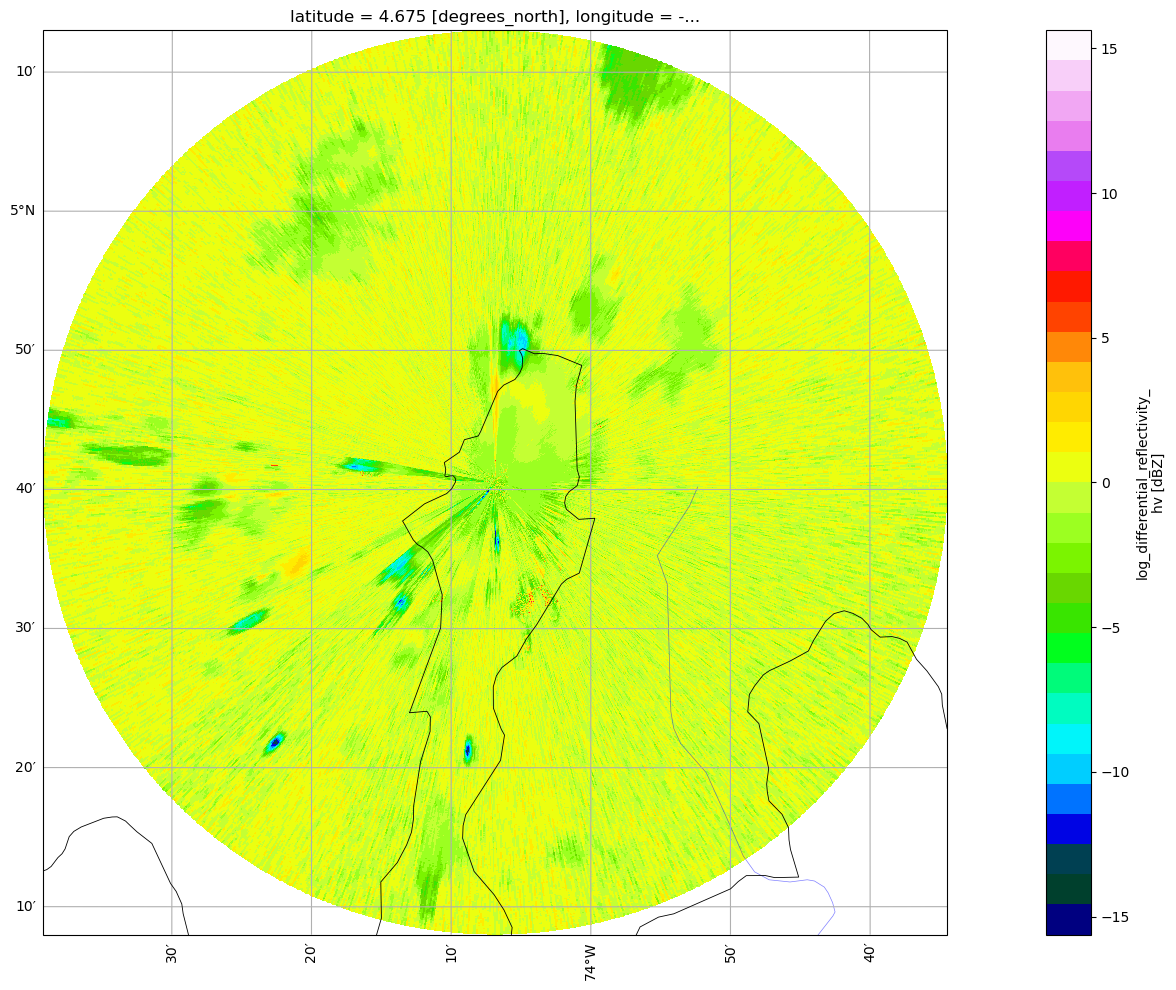

In [802]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [803]:
var = "SNRHC"

<xarray.DataArray 'SNRHC' (azimuth: 1560, range: 960)> Size: 6MB
array([[81.52    , 73.33    , 69.01    , ...,  0.43    ,  0.43    ,  0.43    ],
       [80.659996, 73.33    , 68.15    , ...,  0.43    ,  0.43    ,  1.29    ],
       [78.939995, 72.03    , 66.86    , ...,  1.29    ,  0.43    ,  0.43    ],
       ...,
       [75.92    , 68.15    , 63.41    , ...,  0.43    ,  0.43    ,  0.43    ],
       [76.78    , 67.72    , 64.27    , ...,  0.43    ,  1.29    ,  0.43    ],
       [79.799995, 70.74    , 67.29    , ...,  0.43    ,  0.43    ,  0.43    ]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.216 5.217


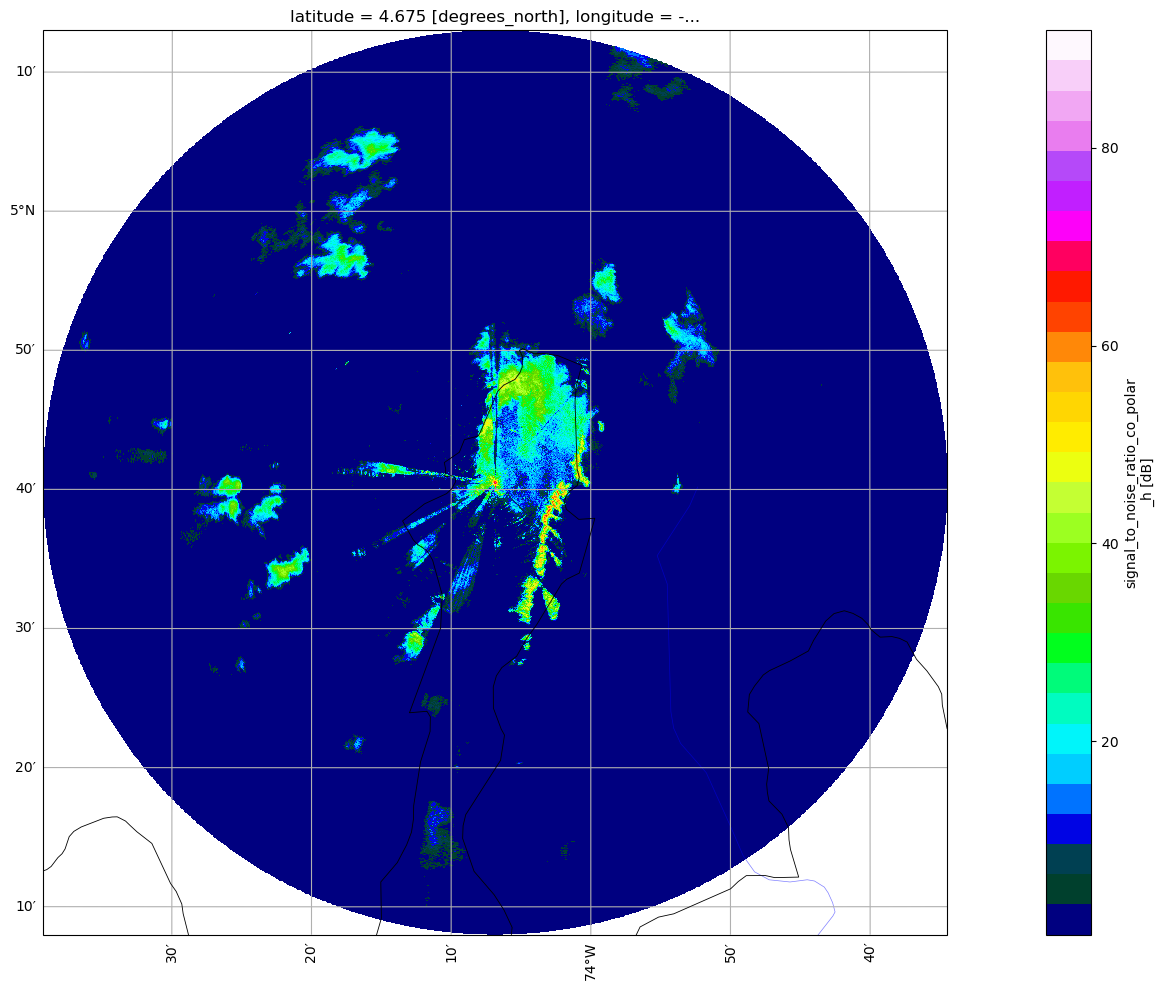

In [804]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [805]:
var = "tPHIDP"

<xarray.DataArray 'tPHIDP' (azimuth: 1560, range: 960)> Size: 12MB
array([[ 34.11640231,  28.65756519,  18.55849961, ..., 102.89036755,
        104.36064647, 128.51108902],
       [148.85388179, 175.17053075, 175.73066217, ..., 122.45815612,
        304.77964632, 160.39742634],
       [215.2955309 , 272.10418501, 266.21358319, ..., 113.11765342,
        108.2258787 , 159.1662849 ],
       ...,
       [ 41.89334952,  37.2587012 ,  12.70603754, ...,  54.46972711,
         49.2431388 ,  22.05306987],
       [ 35.94874552,  30.14951755,  12.23627684, ...,  33.97955426,
         41.11602593,  25.83837988],
       [ 40.89896564,  26.96579526,  12.85970961, ...,  22.08258716,
         49.49378512,  24.59578792]], shape=(1560, 960))
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range        

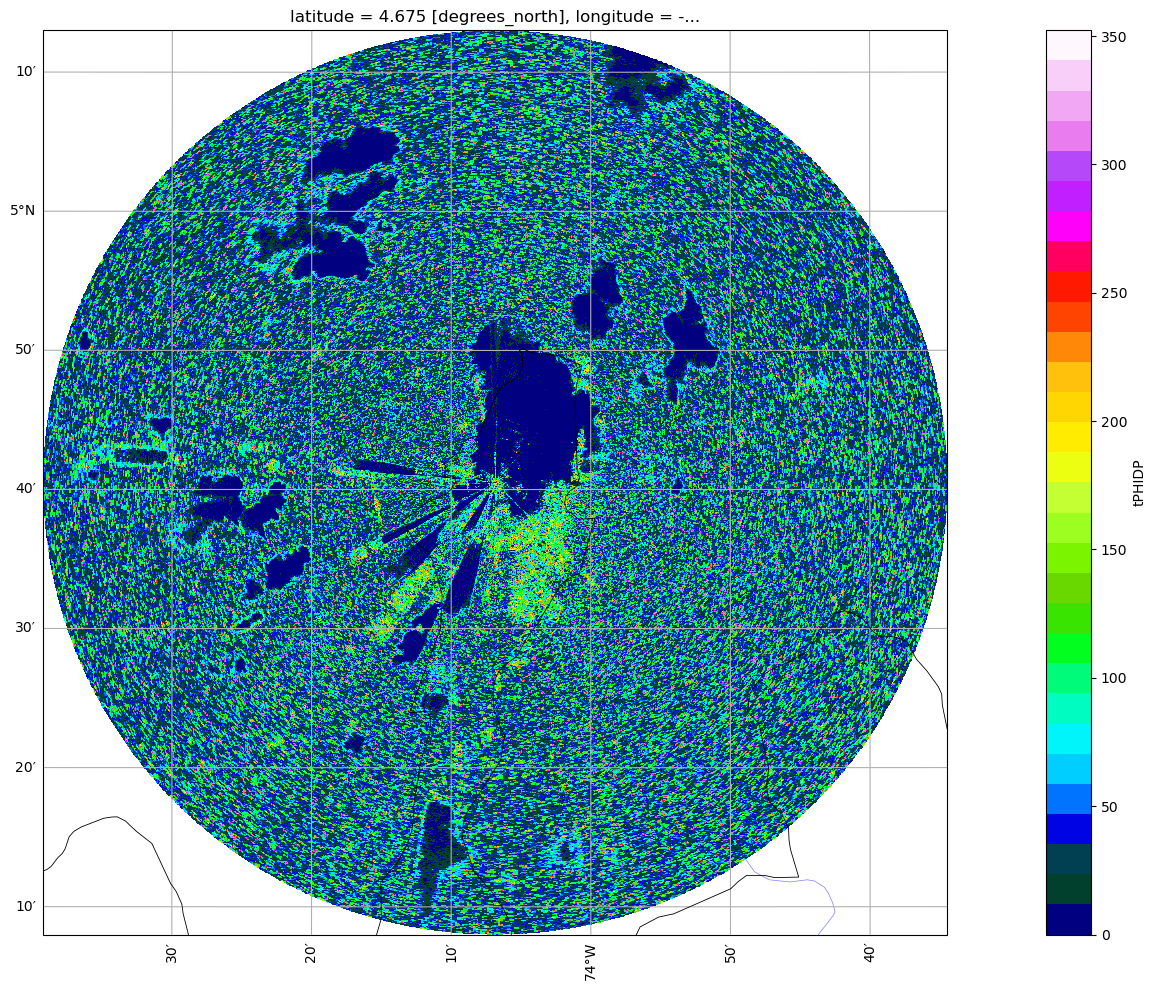

In [806]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [807]:
var = "sPHIDP"

<xarray.DataArray 'sPHIDP' (azimuth: 1560, range: 960)> Size: 6MB
array([[       nan,        nan, 143.84    , ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan, 113.549126, ...,        nan,        nan,
               nan],
       [       nan,        nan, 121.43682 , ...,        nan,        nan,
               nan],
       [       nan,        nan, 131.84648 , ...,        nan,        nan,
               nan]], shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04

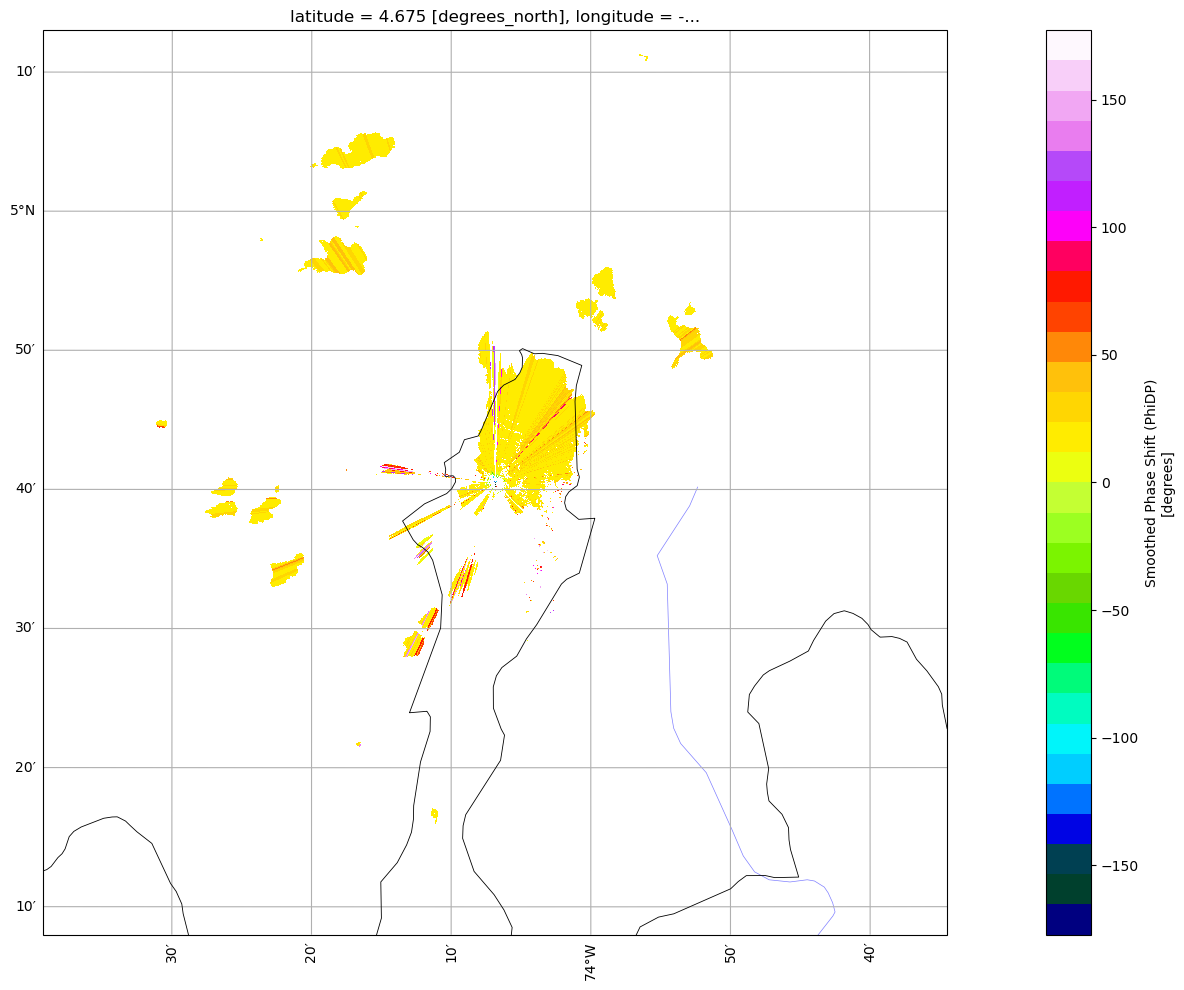

In [808]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [809]:
var = "DR"

<xarray.DataArray 'DR' (azimuth: 1560, range: 960)> Size: 6MB
array([[-15.311882 , -14.327202 , -14.327202 , ...,  -2.2766578,
         -2.4569848,  -2.2803335],
       [-12.823905 , -12.439409 , -12.263719 , ...,  -2.288994 ,
         -2.2952154,  -2.2952154],
       [-12.619173 , -20.266497 , -20.266497 , ...,  -2.6537778,
         -2.479197 ,  -2.4851642],
       ...,
       [-18.518456 , -14.080415 , -13.228272 , ...,  -2.227744 ,
         -2.2217612,  -2.2084281],
       [-29.83635  , -19.347544 , -17.801624 , ...,  -2.299696 ,
         -2.300084 ,  -2.298029 ],
       [-31.356983 , -20.738993 , -20.266495 , ...,  -2.6285336,
         -2.6504784,  -2.6468859]], shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.

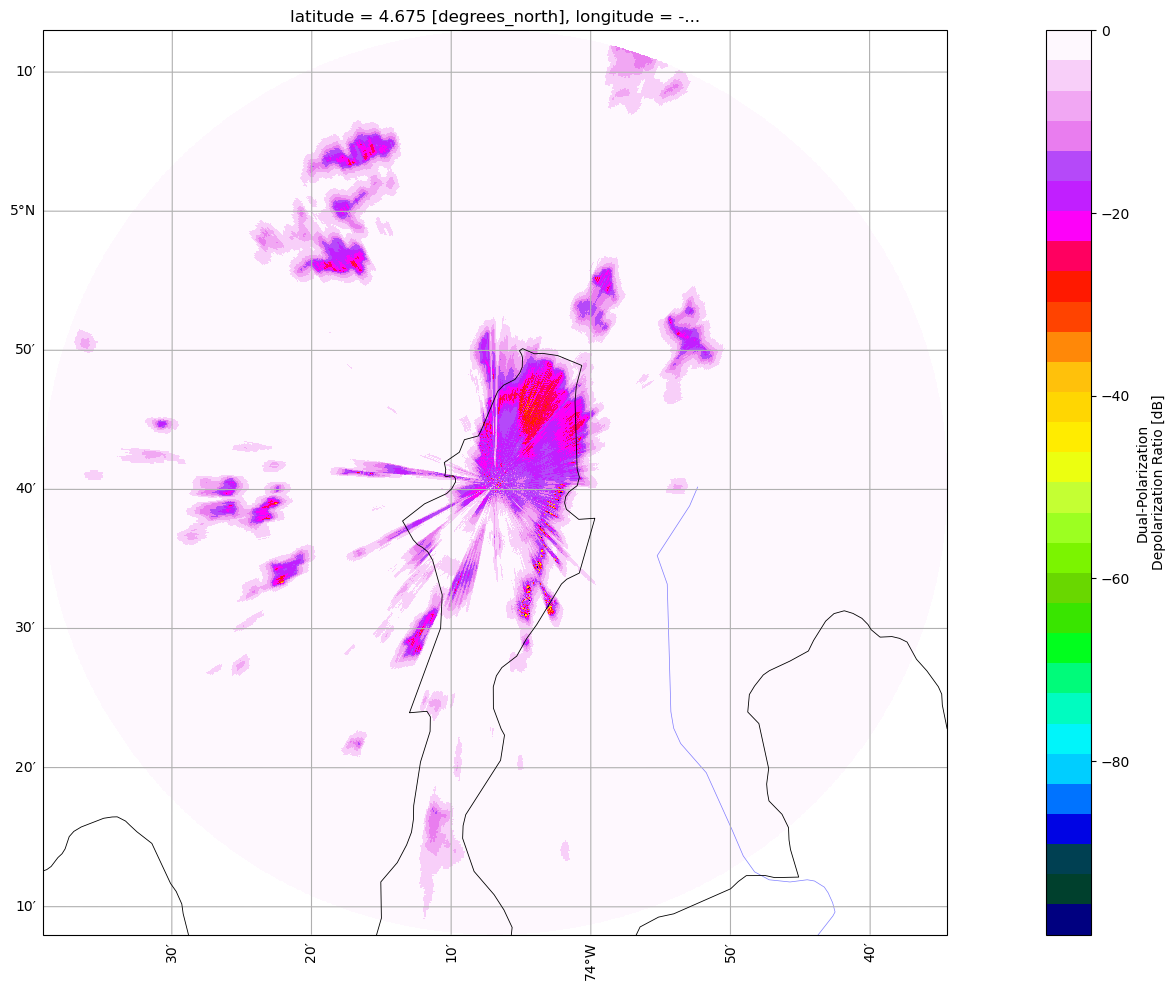

In [810]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmax=0,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [811]:
var = "cKDP"

<xarray.DataArray 'cKDP' (azimuth: 1560, range: 960)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.216 5.217
    gate_longitude  (azimuth, range) float64 12MB -74.11 -74.11 ... -74.12
    gate_height     (azimuth, range) float64 12MB 2.571e+03 ... 5.397e+03
    latitude        float64 8B 4.675
    longitude       float64 8B 

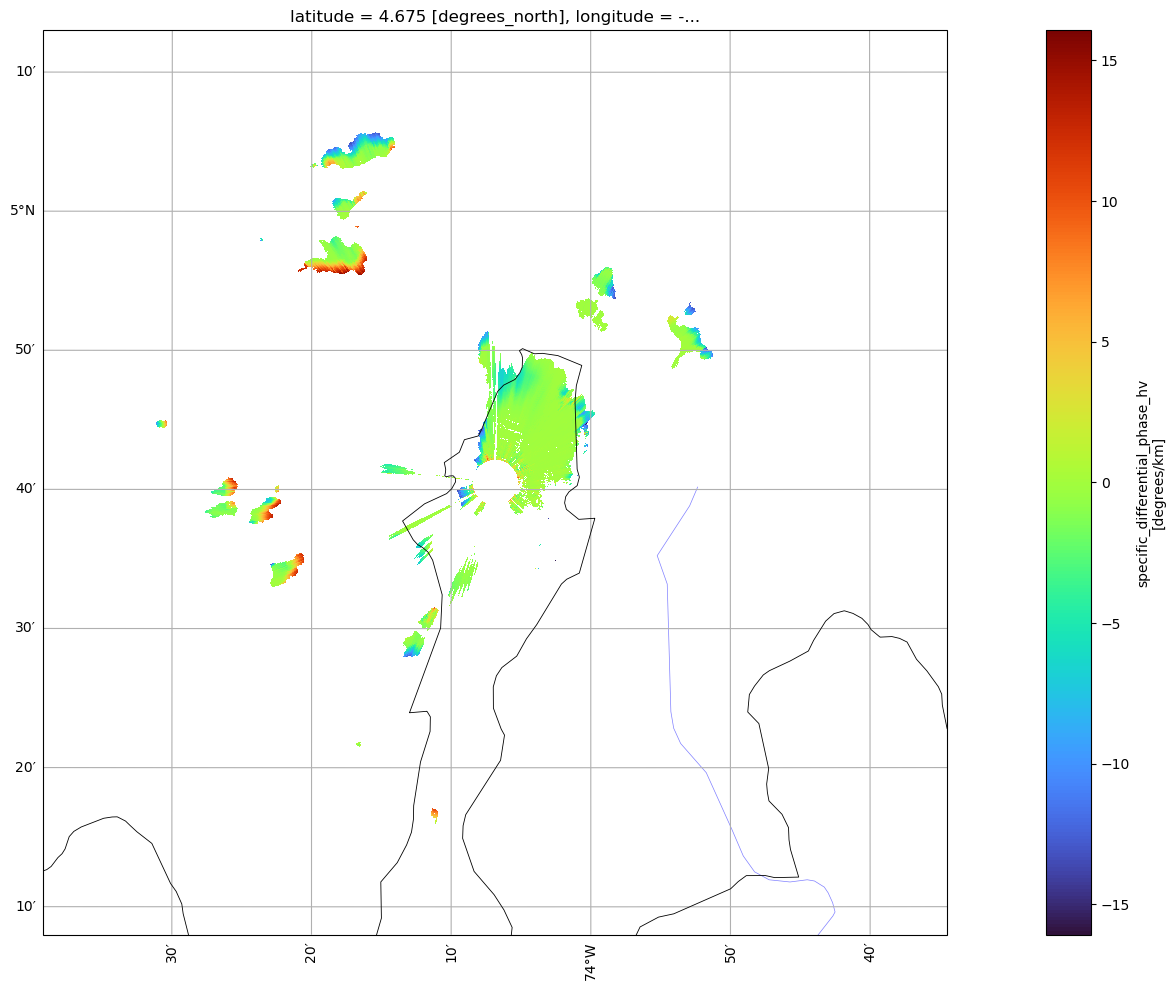

In [812]:
da = swp[f"{var}"]

print(da)
print(np.unique_values(da.values[~np.isnan(da.values)]))

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    #vmin=0,
    #vmax=3,
    cmap="turbo",
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [813]:
var = "dKDP"

<xarray.DataArray 'dKDP' (azimuth: 1560, range: 960)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.216 5.217
    gate_longitude  (azimuth, range) float64 12MB -74.11 -74.11 ... -74.12
    gate_height     (azimuth, range) float64 12MB 2.571e+03 ... 5.397e+03
    latitude        float64 8B 4.675
    longitude       float64 8B 

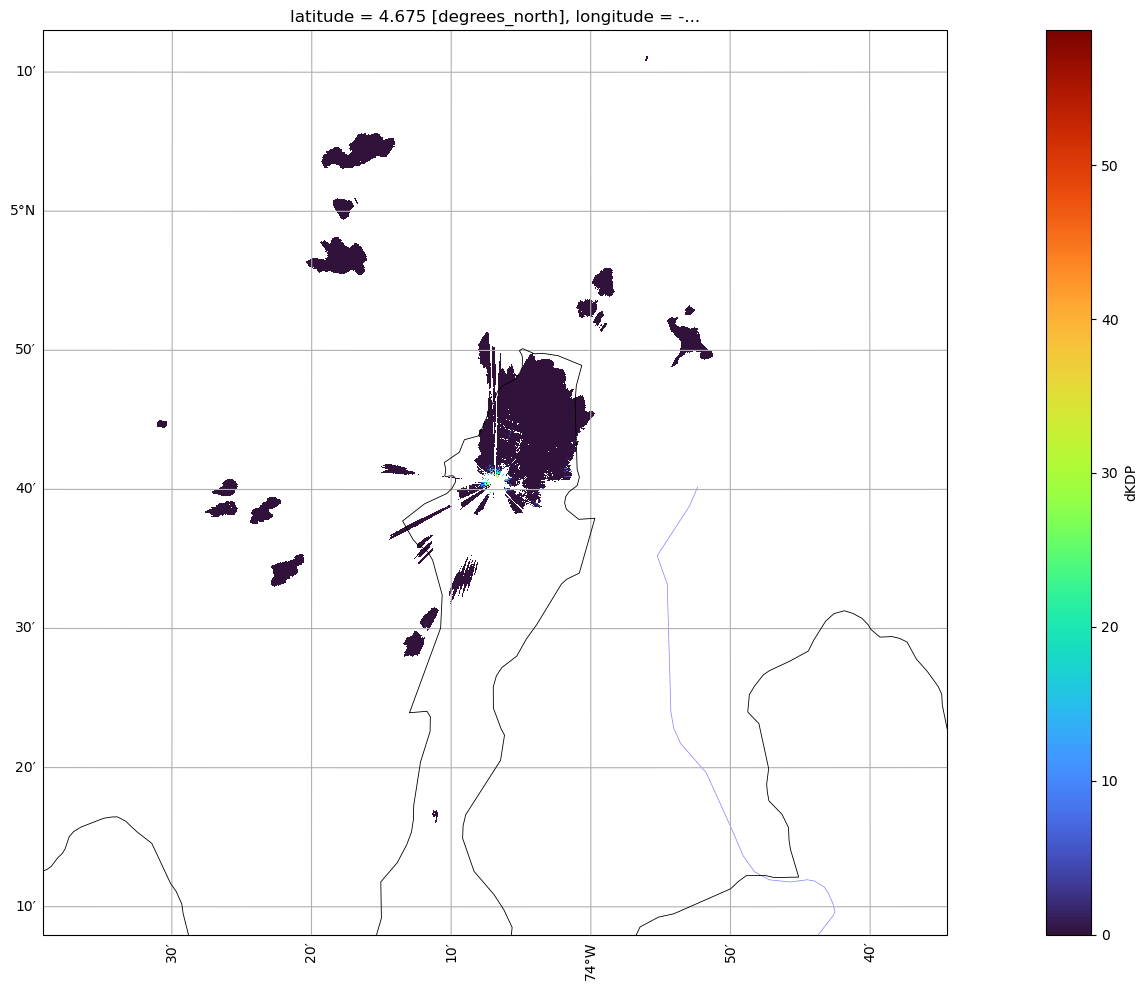

In [814]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)])[::100]:
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap="turbo",
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [815]:
var = "R_A"

<xarray.DataArray 'R_A' (azimuth: 1560, range: 960)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.216 5.217
    gate_longitude  (azimuth, range) float64 12MB -74.11 -74.11 ... -74.12
    gate_height     (azimuth, range) float64 12MB 2.571e+03 ... 5.397e+03
    latitude        float64 8B 4.675
    longitude       float64 8B -

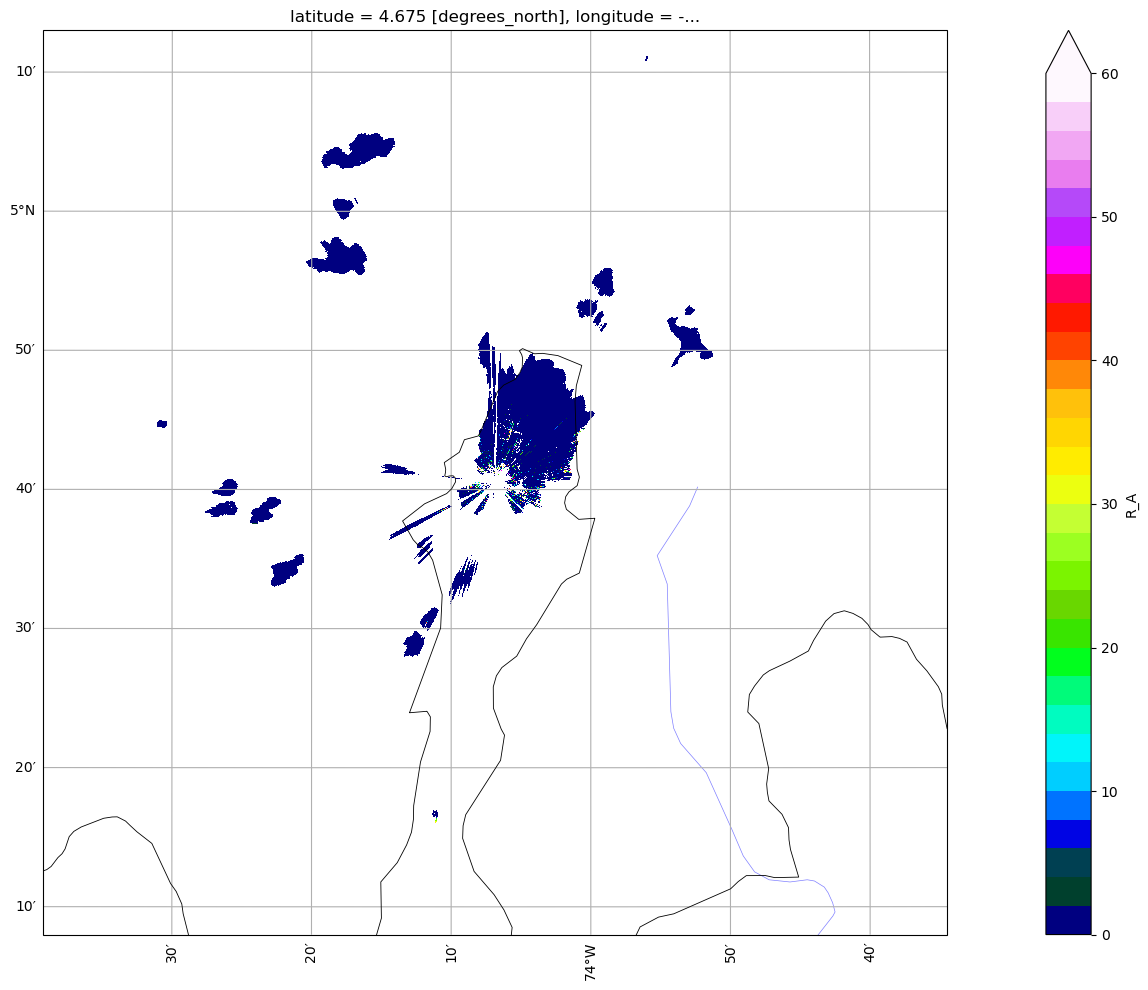

In [816]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)]):
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [817]:
var= "R_Z"

<xarray.DataArray 'R_Z' (azimuth: 1560, range: 960)> Size: 6MB
array([[     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       ...,
       [     nan,      nan, 6.052686, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.01373 0.2444 0.4752 ... 359.6 359.8
    time            (azimuth) float64 12kB 9.0 9.0 9.0 9.0 ... 8.0 8.0 9.0 9.0
    elevation       (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.216 5.217
    gate_longitude  (azimuth, range) f

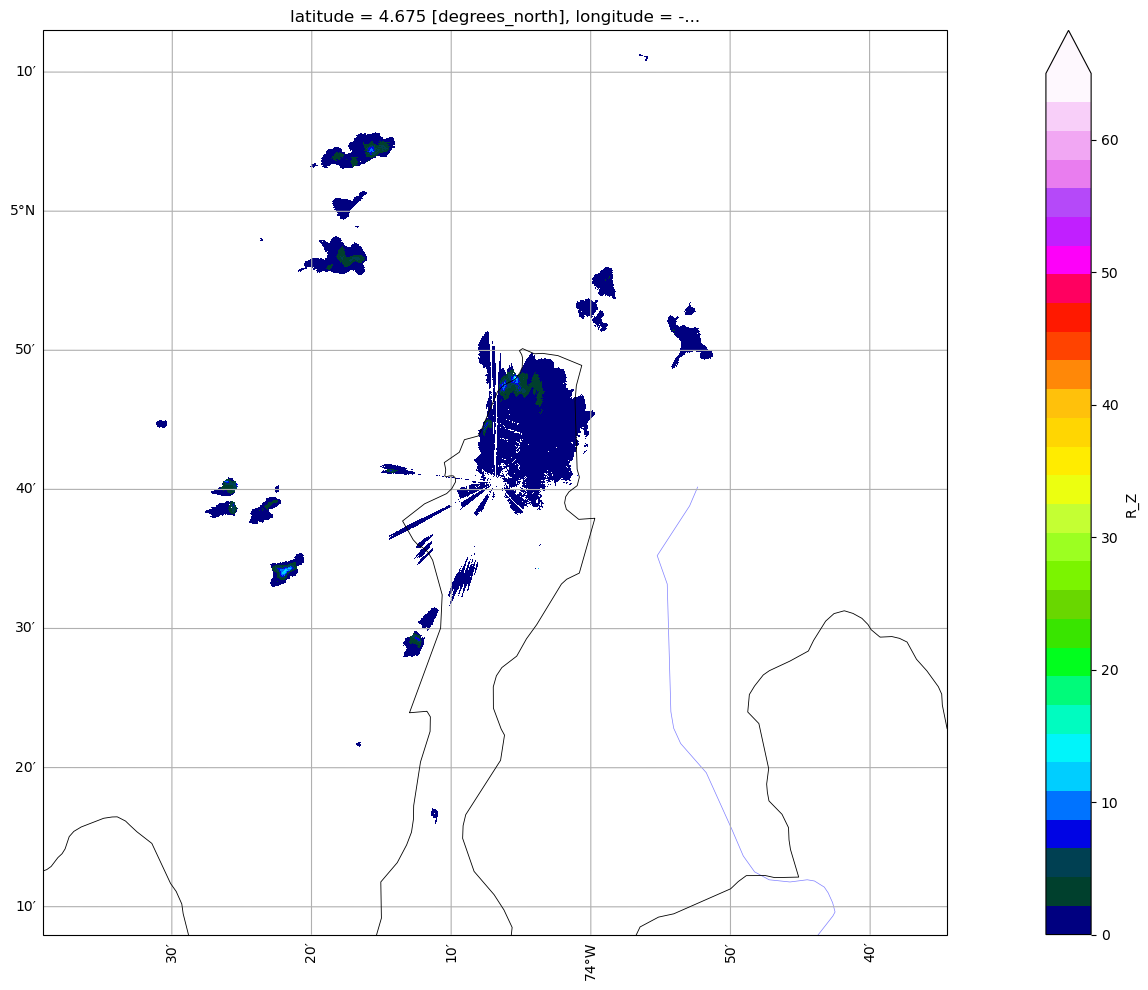

In [821]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)]):
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=65,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [698]:
lat = dtree.latitude.values
lon = dtree.longitude.values
max_range = swp.range.values[-1]/1e3/111

max_lat = lat + max_range
max_lon = lon + max_range
min_lat = lat - max_range
min_lon = lon - max_range

In [699]:
from sodapy import Socrata
import datetime as dt
import pandas as pd

TOKEN = ""

def download_data(date_init: dt.datetime, date_end: dt.datetime) -> pd.DataFrame:
    client = Socrata("www.datos.gov.co", TOKEN)

    date_init = pd.Timestamp(date_init).tz_localize('UTC').tz_convert('America/Bogota')
    date_end  = pd.Timestamp(date_end).tz_localize('UTC').tz_convert('America/Bogota')

    query = client.get(
        dataset_identifier = "s54a-sgyg",
        select             = "codigoestacion, fechaobservacion, latitud, longitud, valorobservado, unidadmedida",
        where              = f"fechaobservacion >= '{date_init.strftime('%Y-%m-%d')}' AND fechaobservacion < '{date_end.strftime('%Y-%m-%d')}'"
                             f"AND latitud > '{min_lat}' AND latitud < '{max_lat}' AND longitud > '{min_lon}' AND longitud < '{max_lon}'",
        limit              = 50000000,
    )

    data = pd.DataFrame.from_records(query)

    return data

In [314]:
time_arr = dtree["time_coverage_start"].values
time_str = time_arr.item().decode('utf-8')
time_pd = pd.to_datetime(time_str)  

start_utc = time_pd - pd.Timedelta(minutes=5)
end_utc   = time_pd + pd.Timedelta(minutes=4)
print(start_utc)
print(end_utc)

df = download_data(dt.datetime(time_pd.year,
                               time_pd.month,
                               time_pd.day),
                   dt.datetime(time_pd.year,
                               time_pd.month,
                               time_pd.day +1+1)) # a dia 12/05/2026 no funciona del tot correctament i has de posar un dia més perquè et retorni el dia que pertoca
print(df)

2024-10-21 18:55:21+00:00
2024-10-21 19:04:21+00:00
       codigoestacion         fechaobservacion      latitud       longitud  \
0          2120500201  2024-10-20T00:00:00.000      4.57515      -74.07175   
1          0021206780  2024-10-20T00:00:00.000     4.619272     -74.194594   
2          2120000100  2024-10-20T00:00:00.000     4.652389     -74.075434   
3          3502500135  2024-10-20T00:00:00.000      4.22553      -73.81481   
4          2120000119  2024-10-20T00:00:00.000     4.555765      -74.09667   
...               ...                      ...          ...            ...   
157593     3502500135  2024-10-21T20:58:00.000      4.22553      -73.81481   
157594     2120500204  2024-10-21T21:00:00.000  4.621556111  -74.104708889   
157595     0035060210  2024-10-21T21:00:00.000      4.65025   -73.64144444   
157596     2120500204  2024-10-21T21:00:00.000  4.621556111  -74.104708889   
157597     0035060210  2024-10-21T21:00:00.000      4.65025   -73.64144444   

       valo

In [315]:
df["fechaobservacion"] = (
    pd.to_datetime(df["fechaobservacion"])
    .dt.tz_localize("America/Bogota")
    .dt.tz_convert("UTC")
)
print(df)

       codigoestacion          fechaobservacion      latitud       longitud  \
0          2120500201 2024-10-20 05:00:00+00:00      4.57515      -74.07175   
1          0021206780 2024-10-20 05:00:00+00:00     4.619272     -74.194594   
2          2120000100 2024-10-20 05:00:00+00:00     4.652389     -74.075434   
3          3502500135 2024-10-20 05:00:00+00:00      4.22553      -73.81481   
4          2120000119 2024-10-20 05:00:00+00:00     4.555765      -74.09667   
...               ...                       ...          ...            ...   
157593     3502500135 2024-10-22 01:58:00+00:00      4.22553      -73.81481   
157594     2120500204 2024-10-22 02:00:00+00:00  4.621556111  -74.104708889   
157595     0035060210 2024-10-22 02:00:00+00:00      4.65025   -73.64144444   
157596     2120500204 2024-10-22 02:00:00+00:00  4.621556111  -74.104708889   
157597     0035060210 2024-10-22 02:00:00+00:00      4.65025   -73.64144444   

       valorobservado unidadmedida  
0             

In [316]:
utc_start = pd.Timestamp(f"{start_utc.year}-{start_utc.month}-{start_utc.day}", tz="UTC") 
utc_end   = pd.Timestamp(f"{start_utc.year}-{start_utc.month}-{start_utc.day + 1}", tz="UTC")
print(utc_start)
print(utc_end)
print(start_utc)

date_filtered_df = df[df["fechaobservacion"].between(utc_start, utc_end)]

#for fecha in date_filtered_df["fechaobservacion"].values:
#    print(fecha)
print(date_filtered_df)

time_utc_start = pd.Timestamp(f"{start_utc.hour}:{start_utc.minute}:00", tz="UTC").time()
time_utc_end   = pd.Timestamp(f"{end_utc.hour}:{end_utc.minute}:00", tz="UTC").time()
time_filtered_df = date_filtered_df[date_filtered_df["fechaobservacion"].dt.time.between(time_utc_start, time_utc_end)]

print(time_filtered_df)

2024-10-21 00:00:00+00:00
2024-10-22 00:00:00+00:00
2024-10-21 18:55:21+00:00
       codigoestacion          fechaobservacion      latitud       longitud  \
102368     3502500135 2024-10-21 00:00:00+00:00      4.22553      -73.81481   
102369     0021208480 2024-10-21 00:00:00+00:00   4.61104201     -74.178333   
102370     0021201200 2024-10-21 00:00:00+00:00      4.34264      -74.18381   
102371     2120000106 2024-10-21 00:00:00+00:00       4.5117  -74.163522222   
102372     2120000103 2024-10-21 00:00:00+00:00      4.73254      -74.01871   
...               ...                       ...          ...            ...   
157527     2120500204 2024-10-21 22:10:00+00:00  4.621556111  -74.104708889   
157528     2120500204 2024-10-21 22:20:00+00:00  4.621556111  -74.104708889   
157529     2120500204 2024-10-21 22:20:00+00:00  4.621556111  -74.104708889   
157530     0035027001 2024-10-21 23:20:00+00:00  4.403388889   -73.94055556   
157531     0035027001 2024-10-21 23:20:00+00:00  4.40

In [317]:
filtered_df = time_filtered_df

In [318]:
print(np.unique_counts(filtered_df["codigoestacion"]))

UniqueCountsResult(values=array([], dtype=object), counts=array([], dtype=int64))


In [319]:
filtered_df["valorobservado"] = pd.to_numeric(filtered_df["valorobservado"].astype(float)*6, errors="coerce")
df = df.dropna(subset=["valorobservado"])

filtered_df["latitud"] = pd.to_numeric(filtered_df["latitud"], errors="coerce")
df = df.dropna(subset=["latitud"])

filtered_df["longitud"] = pd.to_numeric(filtered_df["longitud"], errors="coerce")
df = df.dropna(subset=["longitud"])

print(filtered_df)

Empty DataFrame
Columns: [codigoestacion, fechaobservacion, latitud, longitud, valorobservado, unidadmedida]
Index: []


In [320]:
var="R_Z"
number_of_colors=25

<xarray.DataArray 'R_Z' (azimuth: 1560, range: 960)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.1181 0.3488 0.5795 ... 359.4 359.7 359.9
    time       (azimuth) float64 12kB 50.0 50.0 50.0 50.0 ... 49.0 49.0 50.0
    elevation  (azimuth) float32 6kB 3.005 3.005 3.005 ... 3.005 3.005 3.005
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    longitude  float64 8B -74.11
    altitude   float64 8B 2.57e+03
Attributes:
    long_name:   equivalent_reflectivity_factor_h
    units:       dBZ
    sweep_mode:  ppi
Plotting 0 points
Lon range: nan to nan
Lat range: nan to nan
Empty DataFrame
Columns: [codi

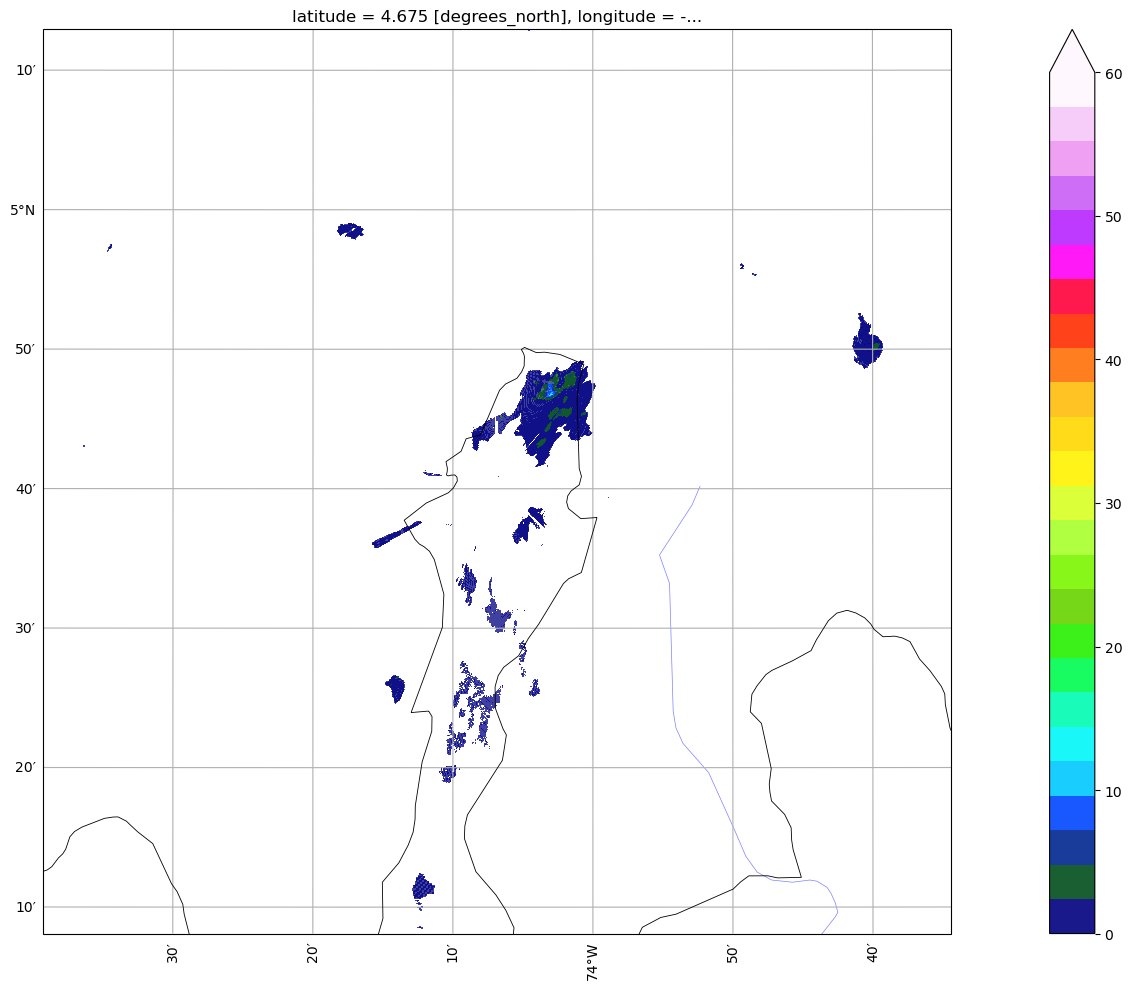

In [321]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
    alpha=0.75
)

filtered_df = filtered_df.dropna(subset=["longitud", "latitud", "valorobservado"])

print(f"Plotting {len(filtered_df)} points")
print(f"Lon range: {filtered_df['longitud'].min():.4f} to {filtered_df['longitud'].max():.4f}")
print(f"Lat range: {filtered_df['latitud'].min():.4f} to {filtered_df['latitud'].max():.4f}")

# ---- Center projection on the data ----
center_lon = filtered_df["longitud"].mean()
center_lat = filtered_df["latitud"].mean()

# ---- Map features ----
department_lines = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    edgecolor='black',
    facecolor='never',
    linewidth=0.6
)

# ---- Separar según valor observado ----
zeros = filtered_df[filtered_df["valorobservado"] == 0]
nonzeros = filtered_df[filtered_df["valorobservado"] > 0]
print(zeros)

# ---- Dibujar puntos con precipitación >0 (relleno con colormap) ----
sc = ax.scatter(
    nonzeros["longitud"],
    nonzeros["latitud"],
    c=nonzeros["valorobservado"],
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    s=50,
    edgecolors="red",
    linewidth=0.9,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    zorder=1,
)

# ---- Dibujar puntos con valor == 0 (solo borde, sin relleno) ----
ax.scatter(
    zeros["longitud"],
    zeros["latitud"],
    facecolors="none",
    edgecolors="black",
    s=20,
    linewidth=0.5,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

cb = plt.colorbar(sc,ax=ax,extend="max")

# ---- Adjust map extent to data bounds with a small margin ----
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

In [ ]:
print(dtree)

gauge_lats = df["latitud"].values
gauge_lons = df["longitud"].values

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 9.3e+09
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       latitude             float64 8B 4.675
│       longitude            float64 8B -74.11
│       altitude             float64 8B ...
│       time_coverage_start  |S25 25B b'2024-10-21T19:00:21Z'
│       time_coverage_end    |S25 25B ...
│       sweep_group_name     (sweep) <U7 28B 'sweep_0'
│       sweep_fixed_angle    (sweep) float32 4B ...
│   Attributes:
│       Conventions:      Cf/Radial instrument_parameters radar_parameters
│       title:            PPIVol
│       institution:      EEC
│       references:       EEC
│       source:           EDGE
│       history:          original
│       comment:          PPIVol
│       instrument_name:  1399BOG
│       site_name:        1399BOG
├── Group: /radar_parameters
│       Di

In [324]:
lon_gauge = filtered_df["longitud"].values
lat_gauge = filtered_df["latitud"].values

print(lon_gauge,lat_gauge)

[] []


In [325]:
gate_lon = swp['gate_longitude'].values
gate_lat = swp['gate_latitude'].values 

radar_precip = swp['R_A'].values

In [326]:
gate_points = np.column_stack([gate_lon.ravel(), gate_lat.ravel()])
tree = cKDTree(gate_points)

gauge_coords = filtered_df[['longitud', 'latitud']].values
distances, indices = tree.query(gauge_coords, k=1)

n_az = gate_lon.shape[0]
n_rng = gate_lon.shape[1]
az_idx = indices // n_rng
rng_idx = indices % n_rng

In [327]:
radar_vals = radar_precip[az_idx, rng_idx]

radar_vals = radar_precip[az_idx, rng_idx]

# Add to station dataframe
filtered_df['radar_precip'] = radar_vals
filtered_df['distance_to_radar_gate_m'] = distances 

In [328]:
# e.g., discard stations farther than 1 km from nearest gate (adjust threshold)
filtered_df = filtered_df[filtered_df['distance_to_radar_gate_m'] < 240000] 

/tmp/ipykernel_4172/3766909635.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


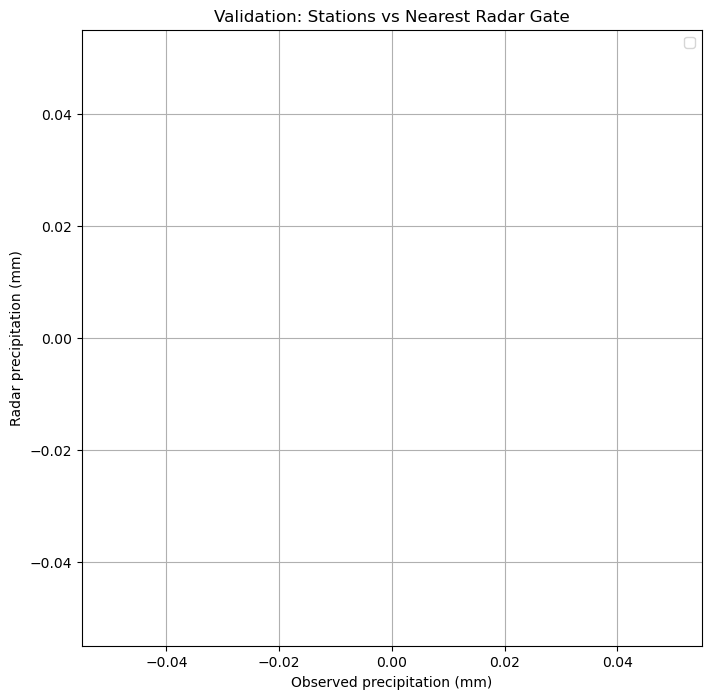

In [329]:
# Keep rows where both are > 0 (or >= some threshold)
#rain = df_obs[(df_obs['valorobservado'] > 0) & (df_obs['radar_precip'] > 0)]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(filtered_df['valorobservado'], filtered_df['radar_precip'], alpha=0.6, edgecolors='k')
#max_val = max(filtered_df['valorobservado'].max(), filtered_df['radar_precip'].max())
#ax.plot([0, max_val], [0, max_val], 'r--', label='1:1 line')
ax.set_xlabel('Observed precipitation (mm)')
ax.set_ylabel('Radar precipitation (mm)')
ax.set_title('Validation: Stations vs Nearest Radar Gate')
ax.grid(True)
ax.legend()
plt.show()

In [335]:
print(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 9.3e+09
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       latitude             float64 8B 4.675
│       longitude            float64 8B -74.11
│       altitude             float64 8B 2.57e+03
│       time_coverage_start  |S25 25B b'2024-10-21T19:00:21Z'
│       time_coverage_end    |S25 25B ...
│       sweep_group_name     (sweep) <U7 28B 'sweep_0'
│       sweep_fixed_angle    (sweep) float32 4B 3.0
│   Attributes:
│       Conventions:      Cf/Radial instrument_parameters radar_parameters
│       title:            PPIVol
│       institution:      EEC
│       references:       EEC
│       source:           EDGE
│       history:          original
│       comment:          PPIVol
│       instrument_name:  1399BOG
│       site_name:        1399BOG
├── Group: /radar_parameters
│    

[2571.63555596 2574.90701134 2578.17892466 2581.45129593 2584.72412515
 2587.99741231 2591.27115741 2594.54536045 2597.82002144 2601.09514037
 2604.37071724 2607.64675205 2610.9232448  2614.20019549 2617.47760412
 2620.75547069 2624.0337952  2627.31257764 2630.59181802 2633.87151634
 2637.1516726  2640.43228679 2643.71335891 2646.99488897 2650.27687697
 2653.55932289 2656.84222675 2660.12558855 2663.40940827 2666.69368593
 2669.97842151 2673.26361503 2676.54926648 2679.83537585 2683.12194316
 2686.40896839 2689.69645155 2692.98439263 2696.27279165 2699.56164859
 2702.85096345 2706.14073624 2709.43096695 2712.72165559 2716.01280216
 2719.30440664 2722.59646904 2725.8889894  2729.18196765 2732.47540379
 2735.76929788 2739.06364992 2742.35845985 2745.65372767 2748.94945343
 2752.24563715 2755.54227875 2758.83937823 2762.13693567 2765.43495104
 2768.73342431 2772.03235545 2775.33174454 2778.63159158 2781.93189649
 2785.23265929 2788.53388003 2791.83555871 2795.13769527 2798.44028972
 2801.

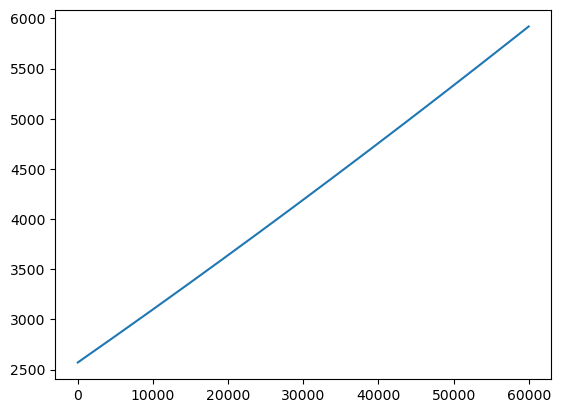

In [339]:
print(swp.isel(azimuth=0)["gate_height"].values)
print(swp.isel(azimuth=0)["range"].values)

plt.plot(swp.isel(azimuth=0)["range"].values, swp.isel(azimuth=0)["gate_height"].values)
plt.show()

In [340]:
import pysoundings

stnm, year, month, day_hour = '80222', '2024', '10', '2112'
data, units = pysoundings.get_data(stnm, year, month, day_hour)
print(data)



None


/home/cesc/anaconda3/envs/radar-env/lib/python3.11/site-packages/pysoundings/main.py:118: UserWarning: No data found for the given parameters
  warnings.warn('No data found for the given parameters')
